# 1. Configuration and Imports
Importing necessary libraries.

In [16]:
# Config
import librosa
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Union, Tuple
import joblib
import pandas as pd # Data analisys

# Sklearn - model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Feature Extraction Function Definitions
Defining functions to extract MFCC features and crawl the directory structure.

In [4]:

def extract_features(file_path: Union[str, Path], n_mfcc=13) -> np.ndarray:
    """Calculates the mean and standard deviation of MFCC coefficients
      to capture spectral characteristics and temporal dynamics of the audio segment.
    """

    y, sr = librosa.load(str(file_path), sr=16000)
    # Calculate MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)
    
    return np.hstack([mfcc_mean, mfcc_std])

def load_dataset(processed_path: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray, dict, list]:
    """
    Crawls the processed data directory to extract features from all samples
      while automatically generating a numeric label mapping based on folder names.
    """
    X, y, file_paths = [], [], []
    label_to_name = {}
    processed_dir = Path(processed_path)
    
    for category_dir in processed_dir.iterdir():
        if not category_dir.is_dir():
            continue

        try:        
            label = int(category_dir.name.split('_')[0])
            clean_name = category_dir.name.split('_', 1)[1].replace('_', ' ').title()
            label_to_name[label] = clean_name
        except (ValueError, IndexError):
            continue

        for file_path in category_dir.glob("*.wav"):
            features = extract_features(file_path=file_path)
            X.append(features)
            y.append(label)
            file_paths.append(str(file_path))

    return np.array(X), np.array(y), label_to_name, file_paths

# 3. Training & Evaluation
Training the Random Forest model and generating basic performance metrics.

In [22]:
# Load data
X, y, target_map, all_paths = load_dataset('../data/processed')
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(X, y, all_paths, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=7, class_weight='balanced')
model.fit(X=X_train,y=y_train)

# Predictions
y_pred = model.predict(X=X_test)
target_names = [target_map[i] for i in sorted(target_map.keys())]

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 94.82%
              precision    recall  f1-score   support

     Ambient       0.97      0.97      0.97      1995
      Speech       0.94      0.98      0.96      2439
    Violence       0.93      0.79      0.86       796

    accuracy                           0.95      5230
   macro avg       0.95      0.91      0.93      5230
weighted avg       0.95      0.95      0.95      5230



# 4. Versioning and Serialization
Creating a new version folder and saving the model, reports and confusion matrix.

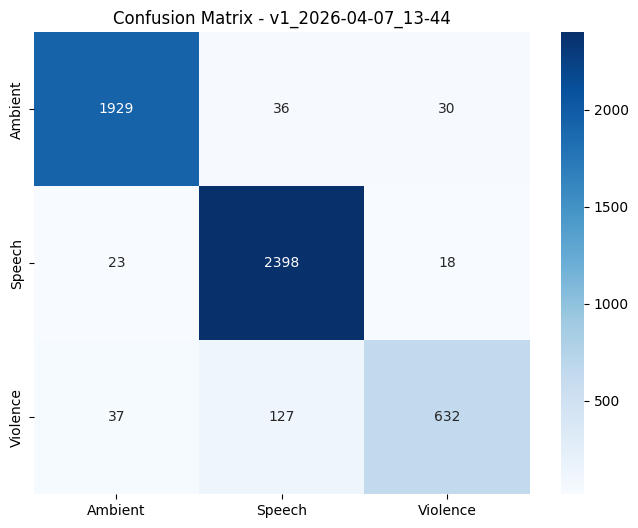

In [ ]:
def get_next_version(base_path: Path) -> str:
    base_path.mkdir(parents=True, exist_ok=True)
    existing = [d.name for d in base_path.iterdir() if d.is_dir() and d.name.startswith('v')]
    version_numbers = []
    for v in existing:
        try:
            num = int(v.split('_')[0][1:])
            version_numbers.append(num)
        except ValueError:
            continue
    
    next_num = max(version_numbers, default=0) + 1
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")

    return f"v{next_num}_{timestamp}"

# Set versioning paths
BASE_DIR_MODEL = Path('../models')
BASE_DIR_REPORT = Path('../reports')
CURRENT_VERSION = get_next_version(BASE_DIR_MODEL)
MODEL_PATH = BASE_DIR_MODEL / CURRENT_VERSION
REPORT_PATH = BASE_DIR_REPORT / CURRENT_VERSION
MODEL_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.mkdir(parents=True, exist_ok=True)

# Save model & name map
joblib.dump(model, MODEL_PATH / 'rf_model.pkl')
joblib.dump(target_map, MODEL_PATH / 'target_map.pkl')

# Save confusion matrix img
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix - {CURRENT_VERSION}")
plt.savefig(REPORT_PATH / 'confusion_matrix.png')
plt.show()

# Save detailed errors to csv
# Create df
analysis_df = pd.DataFrame({
    'file_path': paths_test,
    'true_label': [target_map[i] for i in y_test],
    'predicted_label': [target_map[i] for i in y_pred]
})

# Extract only errors
errors = analysis_df[analysis_df['true_label'] != analysis_df['predicted_label']]
errors.to_csv(REPORT_PATH / 'classification_errors.csv', index=False)

# Save info about latest version to .txt
with open('../latest_version.txt', 'w') as f:
    f.write(CURRENT_VERSION)